# Function 0: 1D tutorial (GP kernels & acquisition)

Explore the effect of kernel parameters and acquisition functions on a simple 1D synthetic function.

- Single input dimension; true function hidden from the GP.
- Sections follow the same layout as Function 1–3: Setup → Visualize → Suggest → Select next query → Illustrate.


## 1. Setup and load data


In [84]:
# ==== External libraries ====
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF, ConstantKernel, WhiteKernel
from skopt.acquisition import gaussian_ei, gaussian_pi, gaussian_lcb
import warnings

repo_root = Path.cwd()
for _ in range(5):
    if (repo_root / "src").exists(): break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.utils.sampling_utils import sample_candidates

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
np.random.seed(42)

In [85]:
# ==== GP datum kernel hyperparameters (used in Sections 3.1 and 3.2) ====
CONSTANT_KERNEL_SCALE = 1.0   # default amplitude
LENGTH_SCALE = 1.0            # default length scale
MATERN_NU = 1.5               # default smoothness (0.5=rough, 2.5=smooth)
GP_ALPHA = 1e-6               # default regularization
WHITE_NOISE_LEVEL = 1e-10     # default white noise (when WhiteKernel used)

# ==== Acquisition function parameters (defaults for next-query selection) ====
XI_EI = 0.01                  # default EI/PI exploration (low=exploit, high=explore)
KAPPA_UCB = 1.0               # default UCB exploration (low=exploit, high=explore)

# Candidate sampling for acquisition: 'sobol' | 'lhs' | 'random' — space-filling for better acquisition maximisation
CANDIDATE_SAMPLING_METHOD = "sobol"
n_cand = 100

In [86]:
# Ensemble acquisition: EI + PI + UCB — agree → use EI; disagree → use centroid
USE_ENSEMBLE = True  # Set False to use EI only (legacy)
AGREE_THRESHOLD = 0.15  # max pairwise L1 dist for 1D

In [87]:
# Range of values for kernel and acquisition parameters (low, default, high)
kernel_scales = [0.1*CONSTANT_KERNEL_SCALE, 1.0*CONSTANT_KERNEL_SCALE, 10.0*CONSTANT_KERNEL_SCALE]
length_scales = [0.95*LENGTH_SCALE, 1.0*LENGTH_SCALE, 1.05*LENGTH_SCALE]
alphas = [0.0001*GP_ALPHA, GP_ALPHA, 1000*GP_ALPHA]
nus = [MATERN_NU - 0.5, MATERN_NU, MATERN_NU + 0.5]
noise_levels = [0.0001*WHITE_NOISE_LEVEL, WHITE_NOISE_LEVEL, 1000*WHITE_NOISE_LEVEL]
xi_values = [0.001, XI_EI, 0.1]
kappa_values = [0.5, KAPPA_UCB, 2.5]

In [88]:
# ==== Synthetic 1D data ====
# True function (hidden from GP): sum of sinusoids + mild trend (multiple local optima)
def true_function(x):
    x = np.asarray(x)
    return (np.sin(x / 2) + 0.5 * np.sin(1.3 * x) + 0.3 * np.cos(x / 1.7)) * 1.5 + 0.1 * x + 1.5

# Observation locations and their (noisy) values from the true function (8 queries)
X_train = np.array([0, 1,  3,  5, 7, 10]).reshape(-1, 1)
rng = np.random.default_rng(42)
y_train = true_function(X_train.ravel()) + rng.normal(0, 0.15, size=len(X_train))
y_train = y_train.reshape(-1, 1)

n_test = 100
X_test = np.linspace(0, 10, n_test).reshape(-1, 1)

# Candidate set for acquisition maximisation (1D, scaled to [0,10])
candidate_pts = sample_candidates(n_cand, 1, method=CANDIDATE_SAMPLING_METHOD, seed=42) * 10
x = X_test.ravel()
y_true = true_function(x).reshape(-1, 1)

# Plot limits from true function range (used in all Section 2/3/5 plots)
y_plot_lo = float(np.min(y_true)) - 0.5
y_plot_hi = float(np.max(y_true)) + 0.5 


### Progress

Best y so far (from observations) — for reference when comparing acquisition suggestions.


In [89]:
# Best y so far (for acquisition functions)
n_obs = len(y_train)
best_y = np.maximum.accumulate(np.ravel(y_train))
print(f"Observations: {n_obs}, best y so far: {best_y[-1]:.4f}")

Observations: 6, best y so far: 3.2602


## 2. Visualize the points

Training data and true function (for tutorial context).


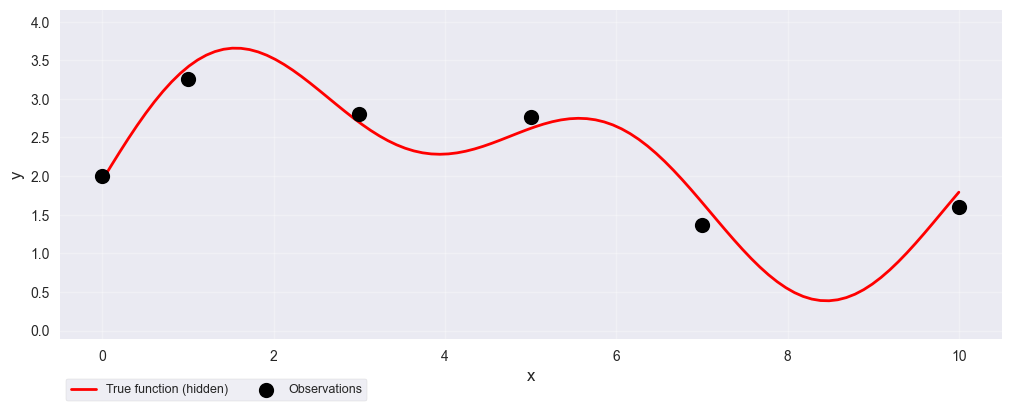

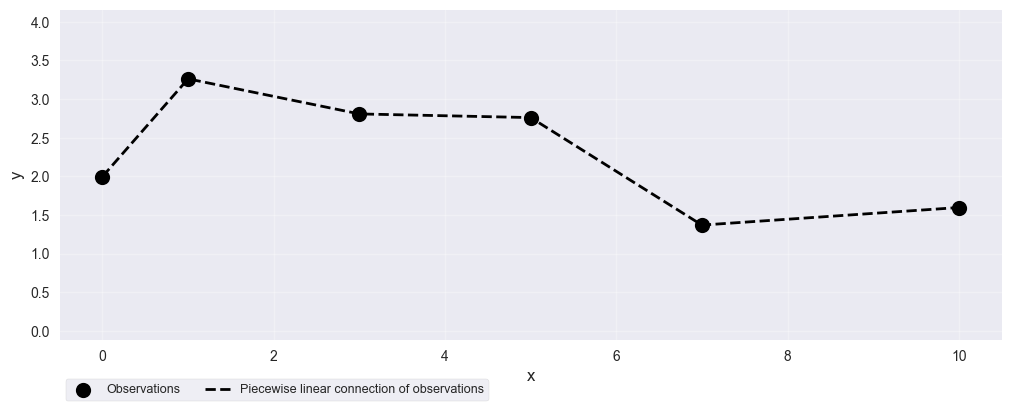

In [90]:
# Plot training data and true function
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.plot(X_test, y_true, "r-", alpha=1.0, label="True function (hidden)", linewidth=2)
ax.scatter(X_train, y_train, c='k', s=80, edgecolors="k", linewidths=2, zorder=10, label="Observations")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=2, frameon=True, bbox_to_anchor=(0.0, -0.1))
ax.grid(True, alpha=0.3)
ax.set_ylim([y_plot_lo, y_plot_hi])
plt.show()

# Plot training data and true function
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.scatter(X_train, y_train, c='k', s=80, edgecolors="k", linewidths=2, zorder=10, label="Observations")
ax.plot(X_train, y_train, "k--", alpha=1.0, label="Piecewise linear connection of observations", linewidth=2)
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=2, frameon=True, bbox_to_anchor=(0.0, -0.1))
ax.grid(True, alpha=0.3)
ax.set_ylim([y_plot_lo, y_plot_hi])
plt.show()


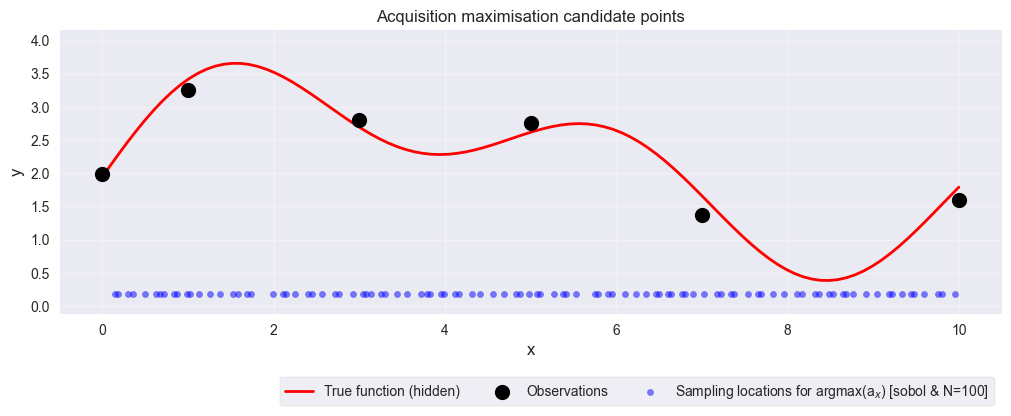

In [91]:
# Plot Sobol candidate points (where acquisition is evaluated)
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
ax.plot(X_test, y_true, "r-", alpha=1.0, label="True function (hidden)", linewidth=2)
ax.scatter(X_train, y_train, c='k', s=80, edgecolors="k", linewidths=2, zorder=10, label="Observations")
# Sobol candidates as rug plot + scatter along bottom
ax.scatter(candidate_pts.ravel(), np.full_like(candidate_pts, y_plot_lo + 0.3), c="blue", alpha=0.5, s=20, label=f"Sampling locations for argmax(a$_x$) [{CANDIDATE_SAMPLING_METHOD} & N={n_cand}]")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_ylim(y_plot_lo, y_plot_hi)
ax.legend(loc="lower right", fontsize=10, frameon=True, framealpha=0.8, ncol=20, bbox_to_anchor=(1.0, -0.35))
ax.set_title("Acquisition maximisation candidate points")
ax.grid(True, alpha=0.3)
plt.show()

## 3. Suggest next point to submit, using Bayesian Optimization Methodology


### 3.1 Surrogate: GP kernels

Effect of kernel parameters on the GP posterior.


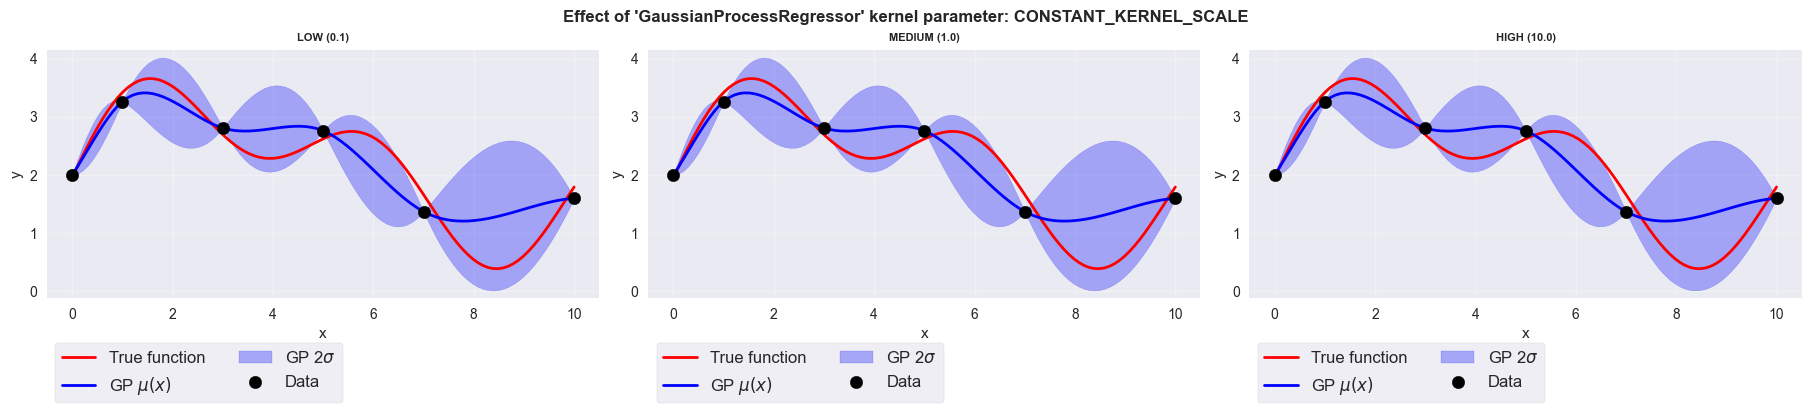

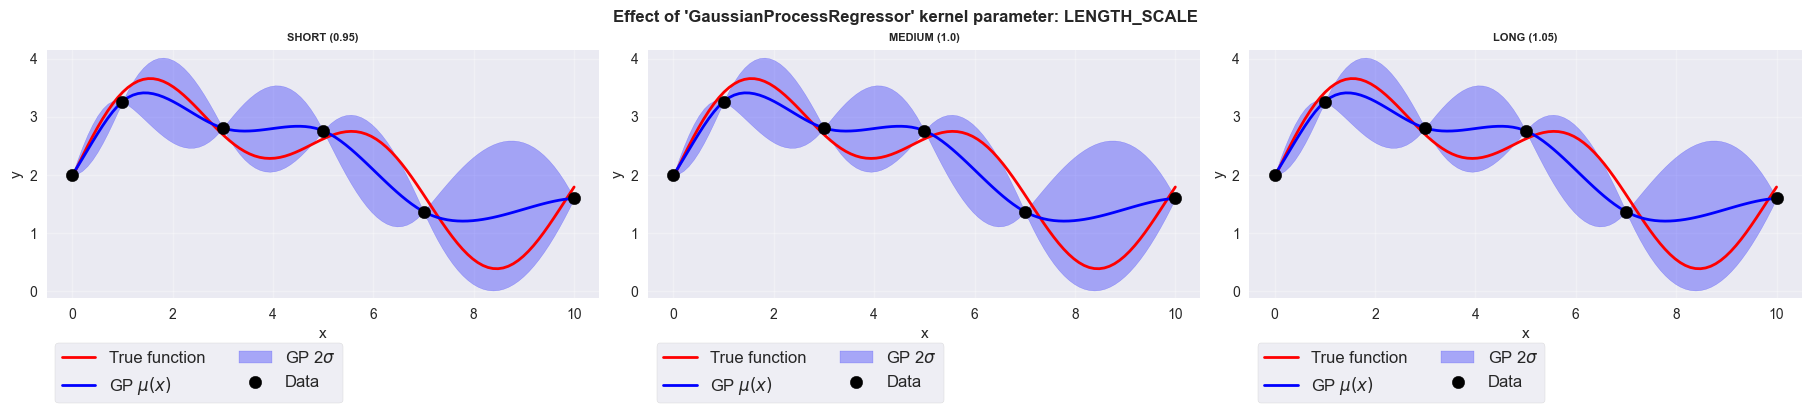

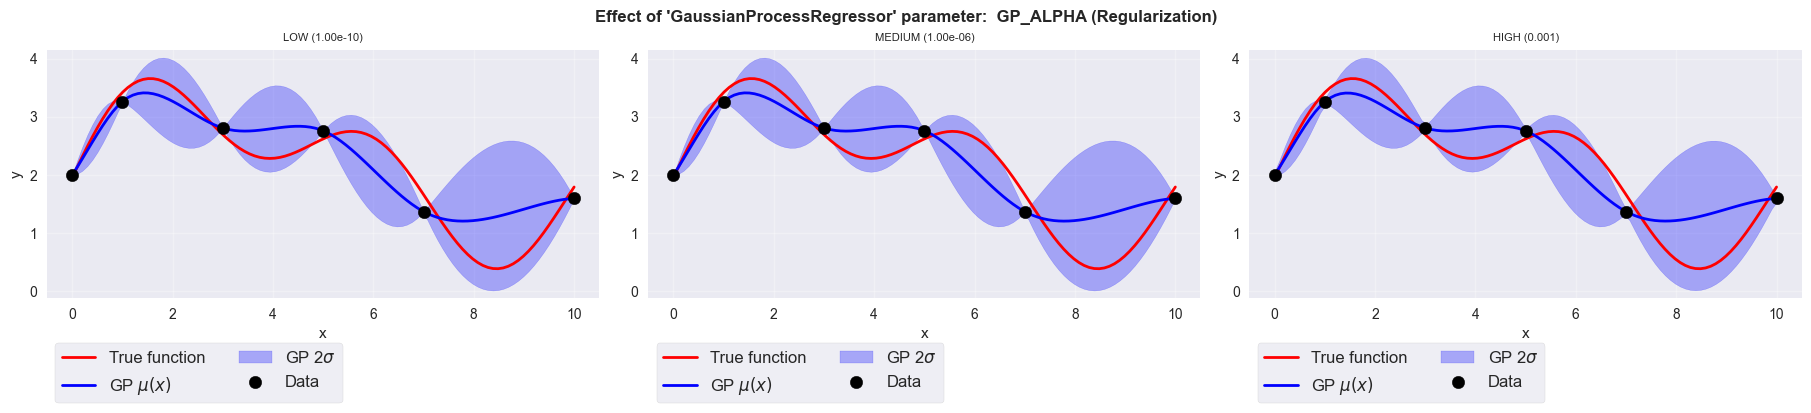

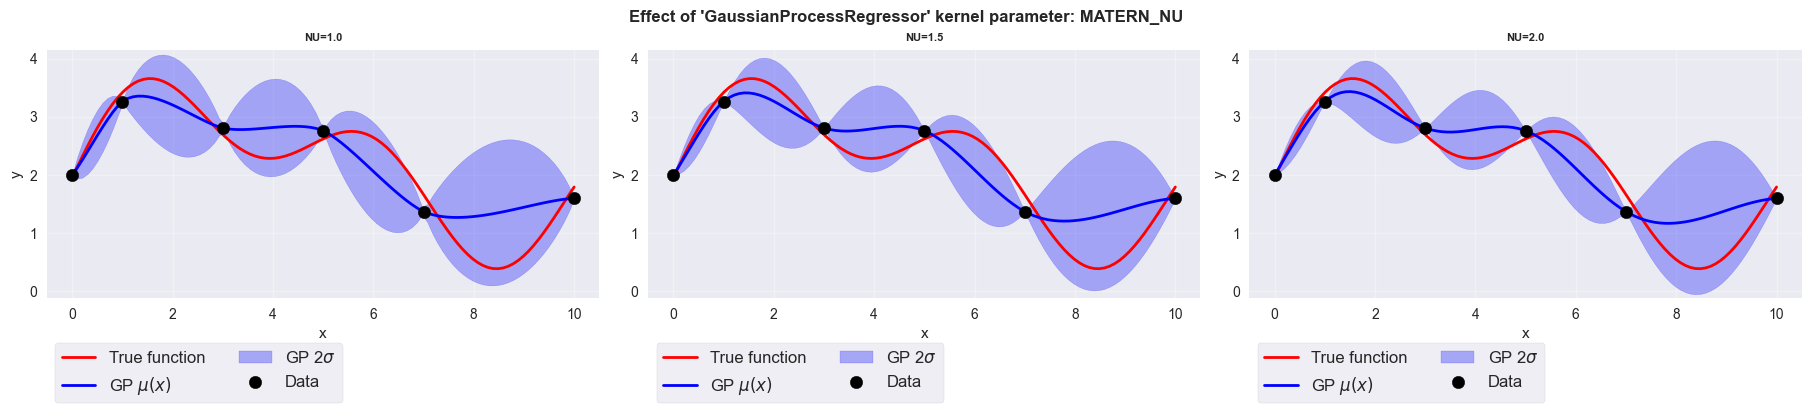

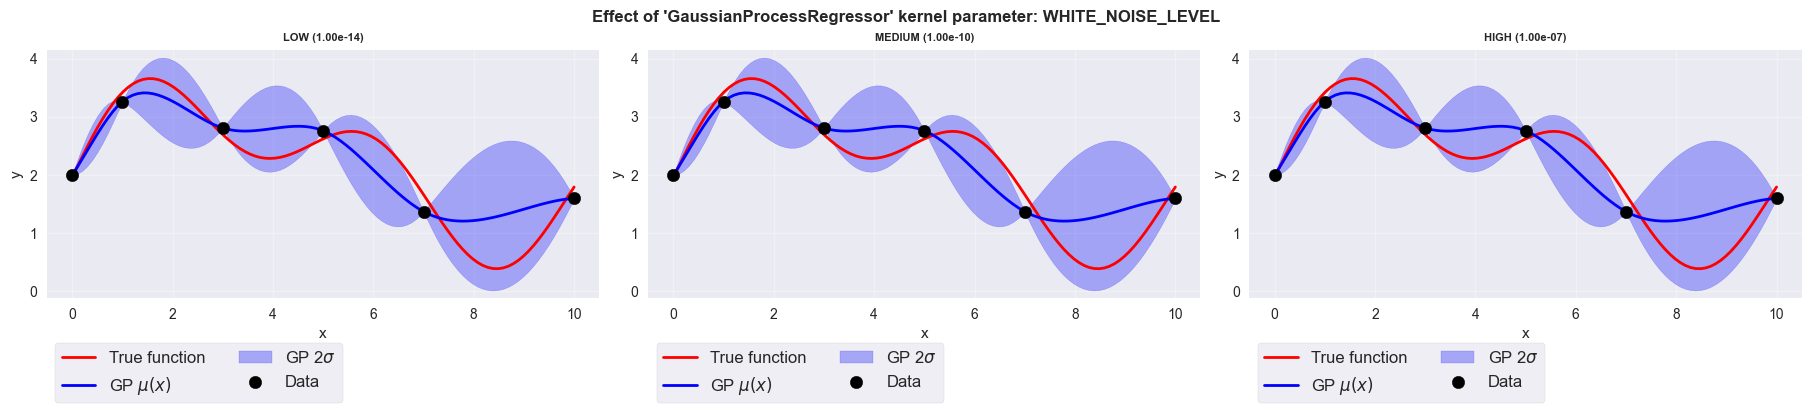

In [92]:
# Range of values for kernel and acquisition parameters (low, default, high)

def _fmt_val(v):
    return f"{v:.2e}" if (abs(v) < 1e-3 or abs(v) >= 1e4) else f"{v}"

def auto_labels(values, names=("LOW", "MEDIUM", "HIGH")):
    return [f"{n} ({_fmt_val(v)})" for n, v in zip(names, values)]

def plot_gp_comparison(param_name, param_values, param_labels, kernel_func):
    fig, axes = plt.subplots(1, len(param_values), figsize=(18, 4), constrained_layout=True)
    fig.suptitle(f"Effect of 'GaussianProcessRegressor' kernel parameter: {param_name}", fontsize=12, fontweight="bold")
    for idx, (param_val, param_label) in enumerate(zip(param_values, param_labels)):
        ax = axes[idx]
        kernel = kernel_func(param_val)
        gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=0)
        gp.fit(X_train, y_train)
        y_pred, sigma = gp.predict(X_test, return_std=True)
        ax.plot(X_test, y_true, "r-", alpha=1.0, label="True function", linewidth=2)
        ax.plot(X_test, y_pred, "b-", label="GP $\mu(x)$", linewidth=2)
        ax.fill_between(X_test.ravel(), y_pred - 1.96*sigma, y_pred + 1.96*sigma, alpha=0.3, color="blue", label="GP 2$\sigma$")
        ax.scatter(X_train, y_train, s=80, c='k', edgecolors="k", zorder=10, label="Data")
        ax.set_title(param_label, fontsize=8, fontweight="bold")
        ax.set_xlabel("x", fontsize=11)
        ax.set_ylabel("y", fontsize=11)
        ax.legend(loc="upper left", fontsize=12, ncol=2, frameon=True, bbox_to_anchor=(0.0, -0.15))
        ax.grid(True, alpha=0.3)
        ax.set_ylim([y_plot_lo, y_plot_hi])
    plt.show()

# 1. CONSTANT_KERNEL_SCALE
plot_gp_comparison("CONSTANT_KERNEL_SCALE", kernel_scales, auto_labels(kernel_scales),
    lambda s: ConstantKernel(s) * Matern(length_scale=1.0, nu=1.5))

# 2. LENGTH_SCALE
plot_gp_comparison("LENGTH_SCALE", length_scales, auto_labels(length_scales, ("SHORT", "MEDIUM", "LONG")),
    lambda ls: ConstantKernel(1.0) * Matern(length_scale=ls, nu=1.5))

# 3. GP_ALPHA
labels_alpha = auto_labels(alphas)
def kernel_with_alpha(alpha):
    return ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5)
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
fig.suptitle("Effect of 'GaussianProcessRegressor' parameter:  GP_ALPHA (Regularization)", fontsize=12, fontweight="bold")
for idx, (alpha, label) in enumerate(zip(alphas, labels_alpha)):
    ax = axes[idx]
    gp = GaussianProcessRegressor(kernel=kernel_with_alpha(alpha), alpha=alpha, n_restarts_optimizer=0)
    gp.fit(X_train, y_train)
    y_pred, sigma = gp.predict(X_test, return_std=True)
    ax.plot(X_test, y_true, "r-", alpha=1.0, linewidth=2, label="True function")
    ax.plot(X_test, y_pred, "b-", linewidth=2, label="GP $\mu(x)$")
    ax.fill_between(X_test.ravel(), y_pred - 1.96*sigma, y_pred + 1.96*sigma, alpha=0.3, color="blue", label="GP 2$\sigma$")
    ax.scatter(X_train, y_train, s=80, c = 'k', edgecolors="k", zorder=10, label="Data")
    ax.set_title(label, fontsize=8)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(True, alpha=0.3); ax.set_ylim([y_plot_lo, y_plot_hi])
    ax.legend(loc="upper left", fontsize=12, ncol=2, frameon=True, bbox_to_anchor=(0.0, -0.15))
plt.show()

# 4. MATERN_NU
labels_nu = [f"NU={v}" for v in nus]
plot_gp_comparison("MATERN_NU", nus, labels_nu,
    lambda nu: ConstantKernel(1.0) * Matern(length_scale=1.0, nu=nu))

# 5. WHITE_NOISE_LEVEL
plot_gp_comparison("WHITE_NOISE_LEVEL", noise_levels, auto_labels(noise_levels),
    lambda noise: ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5) + WhiteKernel(noise_level=noise))


### 3.2 Acquisition functions

EI (Expected Improvement) and UCB (Upper Confidence Bound) with different parameters.


In [93]:
# Fit GP on y (for plots) and gp_neg on -y (skopt acquisition assumes minimization)
kernel = ConstantKernel(CONSTANT_KERNEL_SCALE) * Matern(length_scale=LENGTH_SCALE, nu=MATERN_NU, length_scale_bounds=(1e-3, 100))
gp = GaussianProcessRegressor(kernel=kernel, alpha=GP_ALPHA)
gp.fit(X_train, y_train)
gp_neg = GaussianProcessRegressor(kernel=kernel, alpha=GP_ALPHA)
gp_neg.fit(X_train, -y_train)
mu, sigma = gp.predict(X_test, return_std=True)
sigma = np.maximum(sigma, 1e-9)
f_best = float(np.max(y_train))

# EI, PI, UCB from skopt (on gp_neg: argmax acq on -y equiv to argmax y)
ei_grid = gaussian_ei(candidate_pts, gp_neg, y_opt=-f_best, xi=XI_EI)
pi_grid = gaussian_pi(candidate_pts, gp_neg, y_opt=-f_best, xi=XI_EI)
lcb_grid = gaussian_lcb(candidate_pts, gp_neg, kappa=KAPPA_UCB)
ucb_grid = -lcb_grid  # UCB of y = -LCB of -y


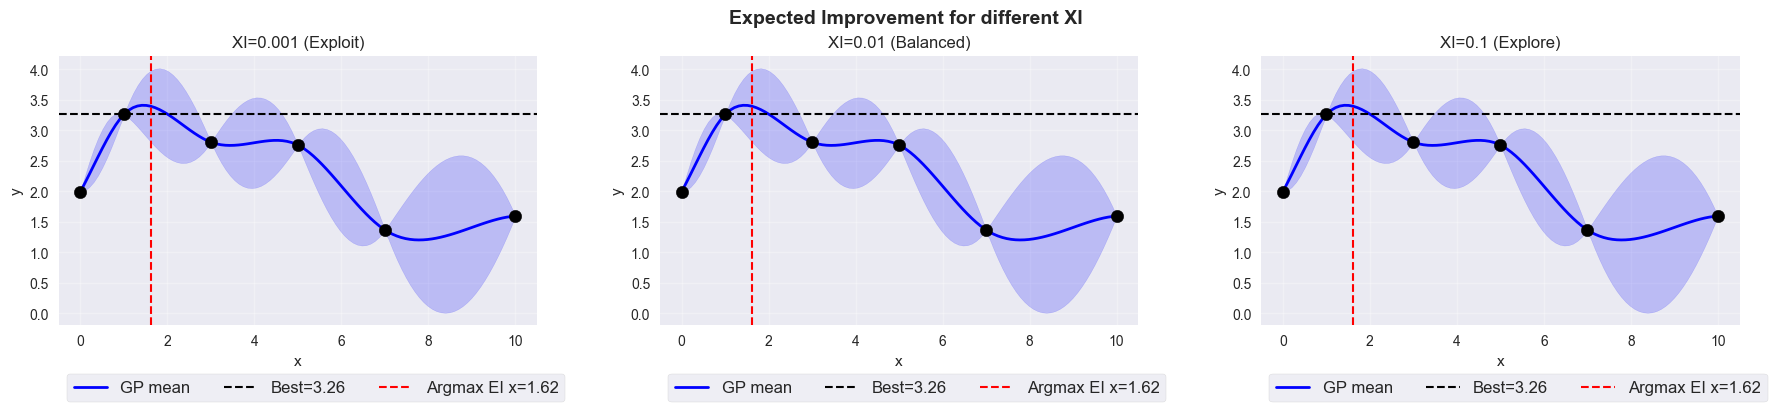

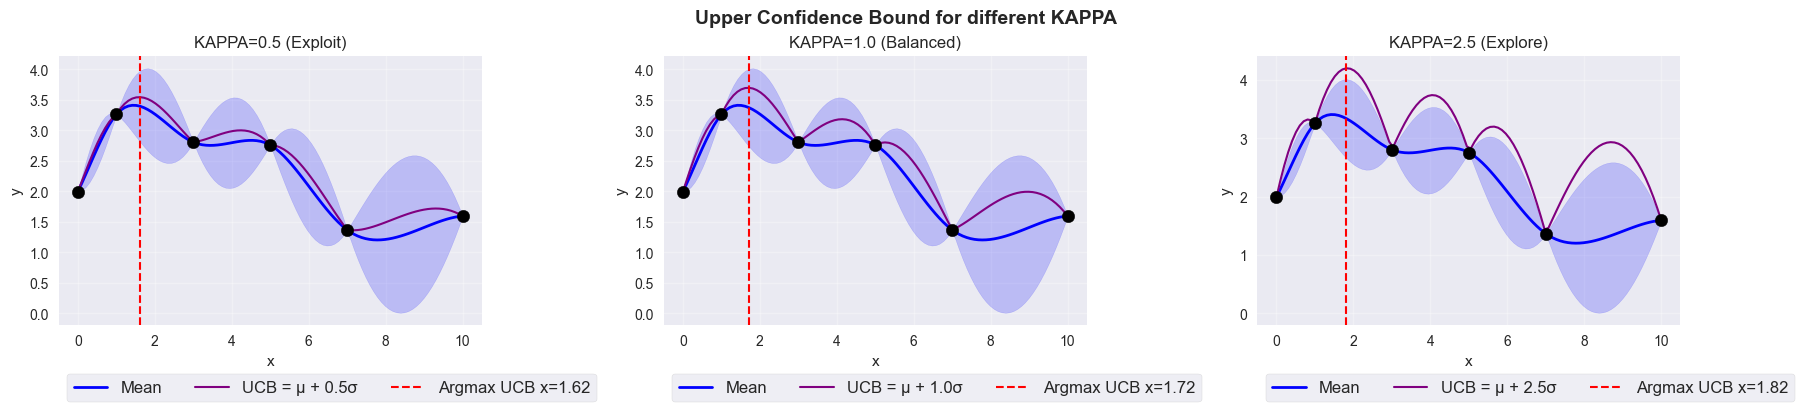

In [94]:
# EI with different XI
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
fig.suptitle("Expected Improvement for different XI", fontsize=14, fontweight="bold")
xi_labels = [f"XI={v} ({q})" for v, q in zip(xi_values, ("Exploit", "Balanced", "Explore"))]
for idx, (xi, label) in enumerate(zip(xi_values, xi_labels)):
    ax = axes[idx]
    ei = gaussian_ei(X_test, gp_neg, y_opt=-f_best, xi=xi)
    ax.plot(X_test, mu, "b-", label="GP mean", linewidth=2)
    ax.fill_between(X_test.ravel(), mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2, color="blue")
    ax.scatter(X_train, y_train, s=80, c='k', edgecolors="k", zorder=10)
    ax.axhline(f_best, color="k", linestyle="--", linewidth=1.5, label=f"Best={f_best:.2f}")
    next_x = X_test[np.argmax(ei)]
    ax.axvline(next_x, color="r", linestyle="--", linewidth=1.5, label=f"Argmax EI x={next_x[0]:.2f}")
    ax.set_title(label, fontsize=12); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=12, ncol=10, frameon=True, bbox_to_anchor=(0.0, -0.15))
plt.show()

# UCB with different KAPPA
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
fig.suptitle("Upper Confidence Bound for different KAPPA", fontsize=14, fontweight="bold")
kappa_labels = [f"KAPPA={v} ({q})" for v, q in zip(kappa_values, ("Exploit", "Balanced", "Explore"))]
for idx, (kappa, label) in enumerate(zip(kappa_values, kappa_labels)):
    ax = axes[idx]
    ucb = -gaussian_lcb(X_test, gp_neg, kappa=kappa)
    ax.plot(X_test, mu, "b-", label="Mean", linewidth=2)
    ax.plot(X_test, ucb, "purple", linewidth=1.5, label=f"UCB = μ + {kappa}σ")
    ax.fill_between(X_test.ravel(), mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.2, color="blue")
    ax.scatter(X_train, y_train, s=80, c='k', edgecolors="k", zorder=10)
    next_x = X_test[np.argmax(ucb)]
    ax.axvline(next_x, color="r", linestyle="--", linewidth=1.5, label=f"Argmax UCB x={next_x[0]:.2f}")
    ax.set_title(label, fontsize=12); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=12, ncol=10, frameon=True, bbox_to_anchor=(0.0, -0.15))
plt.show()


### 3.3 Acquisition function surfaces

EI(x) for different XI values.


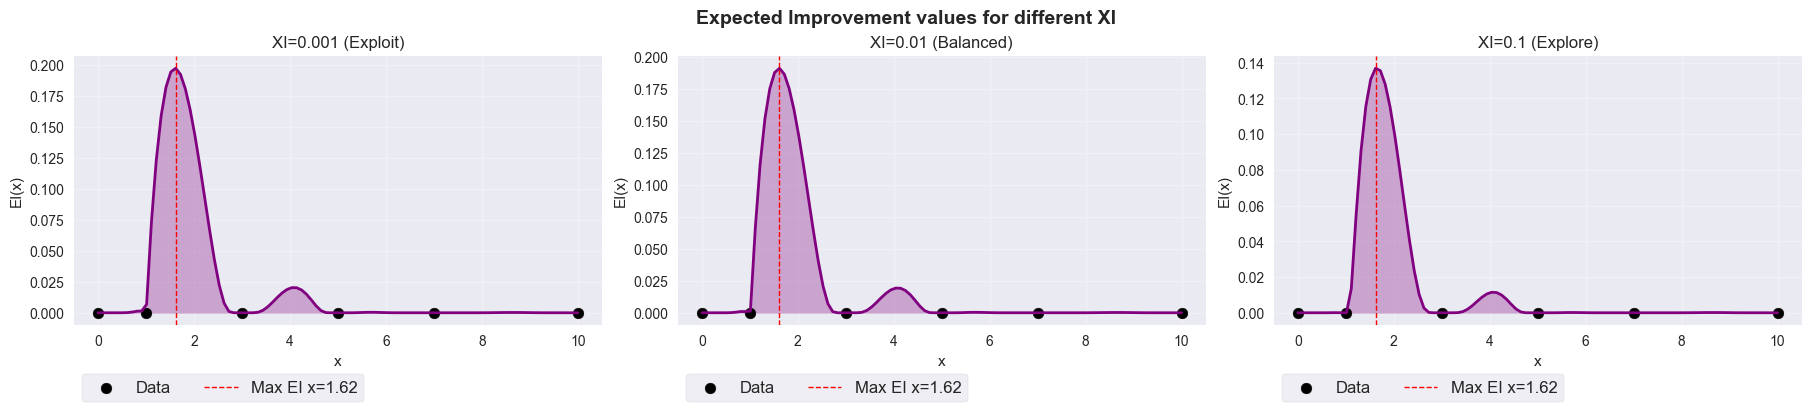

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), constrained_layout=True)
fig.suptitle("Expected Improvement values for different XI", fontsize=14, fontweight="bold")
for idx, (xi, label) in enumerate(zip(xi_values, xi_labels)):
    ax = axes[idx]
    ei = gaussian_ei(X_test, gp_neg, y_opt=-f_best, xi=xi)
    ax.plot(X_test, ei, "purple", linewidth=2)
    ax.fill_between(X_test.ravel(), 0, ei, alpha=0.3, color="purple")
    ax.scatter(X_train, np.zeros_like(X_train), c="black", s=60, edgecolors="k", label="Data")
    next_x = X_test[np.argmax(ei)]
    ax.axvline(next_x, color="r", linestyle="--", linewidth=1, label=f"Max EI x={next_x[0]:.2f}")
    ax.set_title(label, fontsize=12); ax.set_xlabel("x"); ax.set_ylabel("EI(x)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=12, ncol=10, frameon=True, bbox_to_anchor=(0.0, -0.15))
plt.show()


## 4. Select next query

Option for ensemble acquisition: when EI, PI, UCB agree use EI; when they disagree use centroid.


In [96]:
# Maximum acquisition at candidate points
x_EI  = float(candidate_pts.ravel()[np.argmax(ei_grid)])
x_PI  = float(candidate_pts.ravel()[np.argmax(pi_grid)])
x_UCB = float(candidate_pts.ravel()[np.argmax(ucb_grid)])
pts = np.array([x_EI, x_PI, x_UCB])
max_d = max(abs(x_EI-x_PI), abs(x_EI-x_UCB), abs(x_PI-x_UCB))

# Without ensemble: always EI
next_x_no_ens = float(np.clip(x_EI, 0.0, 10.0))

# With ensemble: centroid if disagree, else EI
next_x_with_ens = float(np.clip(np.mean(pts), 0.0, 10.0)) if max_d >= AGREE_THRESHOLD else float(np.clip(x_EI, 0.0, 10.0))

print(f"Without ensemble (EI only):  x = {next_x_no_ens:.4f}")
print(f"With ensemble: EI={x_EI:.4f}, PI={x_PI:.4f}, UCB={x_UCB:.4f} → max_dist={max_d:.4f}")
print(f"  → {'centroid' if max_d >= AGREE_THRESHOLD else 'all agree, EI'} = {next_x_with_ens:.4f}")

# Use chosen mode (USE_ENSEMBLE) for downstream plot
next_x = next_x_with_ens if USE_ENSEMBLE else next_x_no_ens


Without ensemble (EI only):  x = 1.5802
With ensemble: EI=1.5802, PI=1.1329, UCB=1.6920 → max_dist=0.5591
  → centroid = 1.4684


## 5. Illustrate the locations on the proposed query


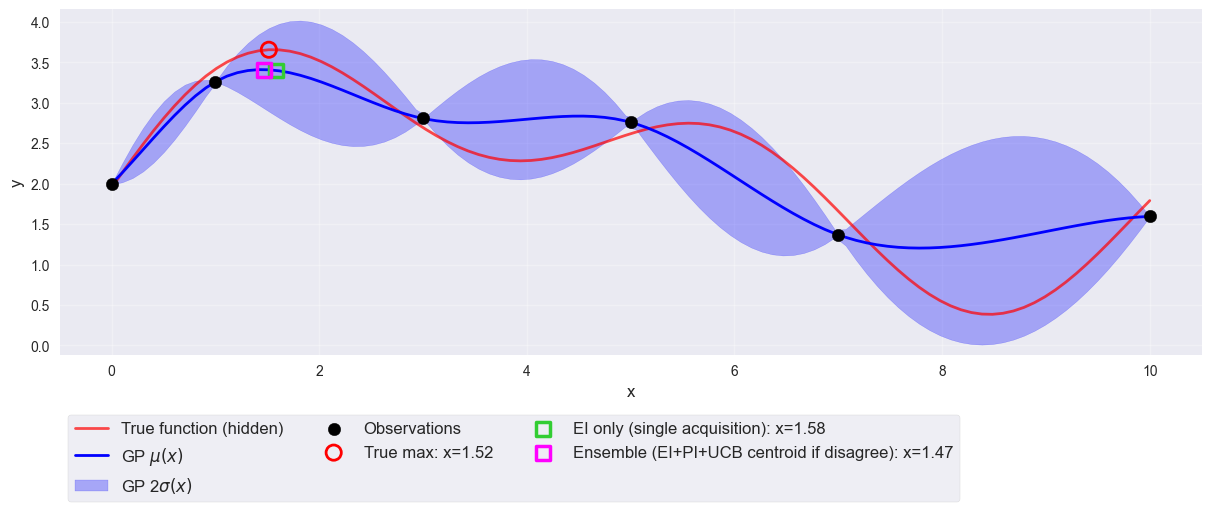

In [109]:
# Summary plot: GP mean + uncertainty, observations, proposed query (hollow red square)
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
ax.plot(X_test, y_true, "r-", alpha=0.7, label="True function (hidden)", linewidth=2)
ax.plot(X_test, mu, "b-", label="GP $\mu(x)$", linewidth=2)
ax.fill_between(X_test.ravel(), mu - 1.96*sigma, mu + 1.96*sigma, alpha=0.3, color="blue", label="GP 2$\sigma(x)$")
ax.scatter(X_train, y_train, s=80, c='k', edgecolors="k", zorder=10, label="Observations")

# True maximum (known for tutorial; GP does not see this)
idx_true_max = np.argmax(y_true)
x_true_max = float(X_test.ravel()[idx_true_max])
y_true_max = float(y_true.ravel()[idx_true_max])
ax.scatter([x_true_max], [y_true_max], c='none', s=120, marker='o', zorder=12, edgecolors='red', linewidths=2, label=f"True max: x={x_true_max:.2f}")

# Proposed queries: both with and without ensemble
y_no_ens = np.interp(next_x_no_ens, X_test.ravel(), mu.ravel())
y_with_ens = np.interp(next_x_with_ens, X_test.ravel(), mu.ravel())
ax.scatter([next_x_no_ens], [y_no_ens], facecolors="none", s=100, marker="s", edgecolors="limegreen", linewidths=2.5, zorder=11, label=f"EI only (single acquisition): x={next_x_no_ens:.2f}")
ax.scatter([next_x_with_ens], [y_with_ens], facecolors="none", s=100, marker="s", edgecolors="magenta", linewidths=2.5, zorder=11, label=f"Ensemble (EI+PI+UCB centroid if disagree): x={next_x_with_ens:.2f}")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.legend(loc="upper left", fontsize=12, ncol=3, frameon=True, bbox_to_anchor=(0.0, -0.15))
ax.grid(True, alpha=0.3)
ax.set_ylim([y_plot_lo, y_plot_hi])
plt.show()


### Summary of effects

| Parameter | Increase → | Decrease → |
|-----------|------------|------------|
| CONSTANT_KERNEL_SCALE | Larger magnitude swings | Smaller, tighter predictions |
| LENGTH_SCALE | SMOOTHER (global) | ROUGHER (local, wiggly) |
| GP_ALPHA | More regularized, stable | Tighter fit, risk instability |
| MATERN_NU | Smoother prior | Rougher prior |
| WHITE_NOISE_LEVEL | Higher uncertainty | Lower uncertainty |
| XI (EI) | EXPLORE more | EXPLOIT more |
| KAPPA (UCB) | EXPLORE more | EXPLOIT more |
